4-1-1 Find x(t) using the second‐order Runge‐Kutta method with h=0.01 

[RK2 결과] t=2.0 에서의 값: 26.784837 (오차: 1.423761e-02)


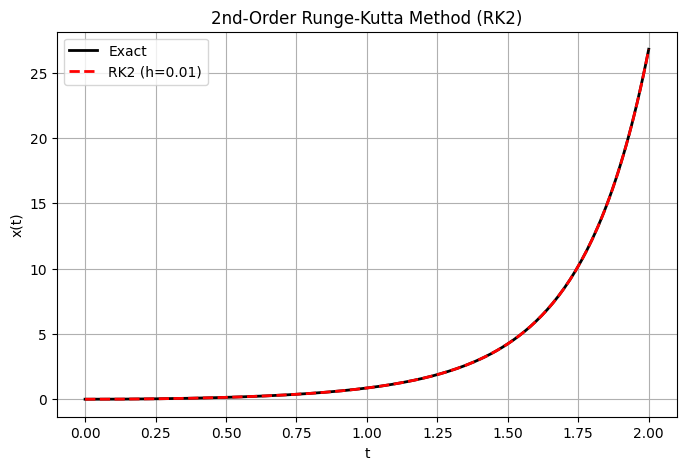

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return t + 2 * x * t

def exact_solution(t):
    return 0.5 * (np.exp(t**2) - 1)

t0, x0 = 0.0, 0.0
t_end = 2.0
h = 0.01
N = int((t_end - t0) / h)

t = np.linspace(t0, t_end, N + 1)
x_rk2 = np.zeros(N + 1)
x_rk2[0] = x0

for i in range(N):
    t_n = t[i]
    x_n = x_rk2[i]
    
    k1 = f(t_n, x_n)
    k2 = f(t_n + h, x_n + h * k1)
    
    x_rk2[i+1] = x_n + (h / 2.0) * (k1 + k2)

x_exact = exact_solution(t)
error = np.abs(x_exact - x_rk2)

print(f"[RK2 결과] t=2.0 에서의 값: {x_rk2[-1]:.6f} (오차: {error[-1]:.6e})")

plt.figure(figsize=(8, 5))
plt.plot(t, x_exact, 'k-', lw=2, label='Exact')
plt.plot(t, x_rk2, 'r--', lw=2, label='RK2 (h=0.01)')
plt.title('2nd-Order Runge-Kutta Method (RK2)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.show()

4-1-2 Find x(t) using the fourth‐order Runge‐Kutta method with h=0.01

[RK4 결과] t=2.0 에서의 값: 26.799074 (오차: 7.558046e-07)


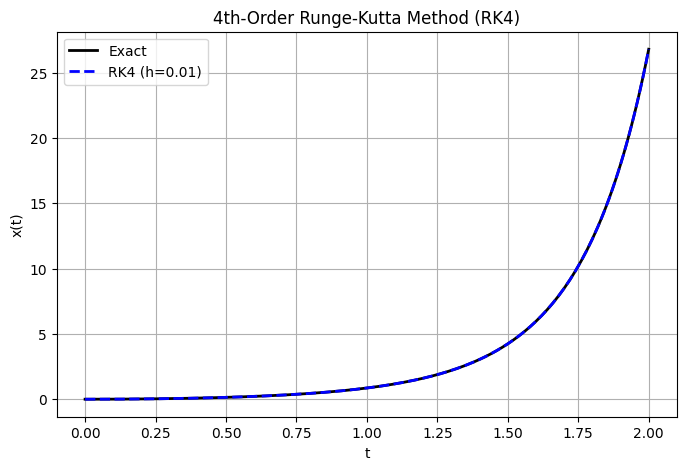

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return t + 2 * x * t

def exact_solution(t):
    return 0.5 * (np.exp(t**2) - 1)

t0, x0 = 0.0, 0.0
t_end = 2.0
h = 0.01
N = int((t_end - t0) / h)

t = np.linspace(t0, t_end, N + 1)
x_rk4 = np.zeros(N + 1)
x_rk4[0] = x0

for i in range(N):
    t_n = t[i]
    x_n = x_rk4[i]
    
    k1 = f(t_n, x_n)
    k2 = f(t_n + 0.5*h, x_n + 0.5*h*k1)
    k3 = f(t_n + 0.5*h, x_n + 0.5*h*k2)
    k4 = f(t_n + h, x_n + h*k3)
    
    x_rk4[i+1] = x_n + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

x_exact = exact_solution(t)
error = np.abs(x_exact - x_rk4)

print(f"[RK4 결과] t=2.0 에서의 값: {x_rk4[-1]:.6f} (오차: {error[-1]:.6e})")

plt.figure(figsize=(8, 5))
plt.plot(t, x_exact, 'k-', lw=2, label='Exact')
plt.plot(t, x_rk4, 'b--', lw=2, label='RK4 (h=0.01)')
plt.title('4th-Order Runge-Kutta Method (RK4)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.show()

4-1-3 accuracy 분석

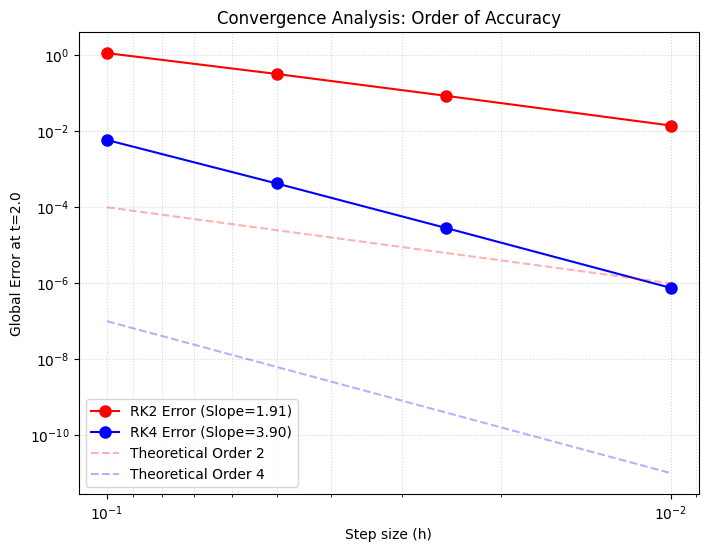

h = [0.1, 0.05, 0.025, 0.01]
RK2 Errors: [np.float64(1.1481121118787883), np.float64(0.3242536467562189), np.float64(0.08598244828043278), np.float64(0.014237607087551396)]
RK4 Errors: [np.float64(0.0059206662572854896), np.float64(0.0004238786017687346), np.float64(2.8349461189236536e-05), np.float64(7.558046171141086e-07)]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return t + 2 * x * t

def exact_solution(t):
    return 0.5 * (np.exp(t**2) - 1)

def solve_rk2(h):
    t_end = 2.0
    N = int(t_end / h)
    t = np.linspace(0, t_end, N + 1)
    x = np.zeros(N + 1)
    x[0] = 0.0
    
    for i in range(N):
        k1 = f(t[i], x[i])
        k2 = f(t[i] + h, x[i] + h * k1)
        x[i+1] = x[i] + (h / 2.0) * (k1 + k2)
    return t, x

def solve_rk4(h):
    t_end = 2.0
    N = int(t_end / h)
    t = np.linspace(0, t_end, N + 1)
    x = np.zeros(N + 1)
    x[0] = 0.0
    
    for i in range(N):
        k1 = f(t[i], x[i])
        k2 = f(t[i] + 0.5*h, x[i] + 0.5*h*k1)
        k3 = f(t[i] + 0.5*h, x[i] + 0.5*h*k2)
        k4 = f(t[i] + h, x[i] + h*k3)
        x[i+1] = x[i] + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return t, x

h_list = [0.1, 0.05, 0.025, 0.01] 
rk2_errors = []
rk4_errors = []

for h in h_list:

    t2, x2 = solve_rk2(h)
    error2 = np.abs(exact_solution(2.0) - x2[-1]) 
    rk2_errors.append(error2)
    

    t4, x4 = solve_rk4(h)
    error4 = np.abs(exact_solution(2.0) - x4[-1])
    rk4_errors.append(error4)


slope_rk2 = np.polyfit(np.log(h_list), np.log(rk2_errors), 1)[0]
slope_rk4 = np.polyfit(np.log(h_list), np.log(rk4_errors), 1)[0]


plt.figure(figsize=(8, 6))


plt.loglog(h_list, rk2_errors, 'ro-', markersize=8, label=f'RK2 Error (Slope={slope_rk2:.2f})')
plt.loglog(h_list, rk4_errors, 'bo-', markersize=8, label=f'RK4 Error (Slope={slope_rk4:.2f})')


plt.loglog(h_list, [1e-2 * h**2 for h in h_list], 'r--', alpha=0.3, label='Theoretical Order 2')
plt.loglog(h_list, [1e-3 * h**4 for h in h_list], 'b--', alpha=0.3, label='Theoretical Order 4')

plt.xlabel('Step size (h)')
plt.ylabel('Global Error at t=2.0')
plt.title('Convergence Analysis: Order of Accuracy')
plt.legend()
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.gca().invert_xaxis() 
plt.show()

print(f"h = {h_list}")
print(f"RK2 Errors: {rk2_errors}")
print(f"RK4 Errors: {rk4_errors}")

4-1-4 다른 step size h = 0.01, 0.05, 0.1 분석

h          Numerical x(2)       Exact x(2)           Error               
----------------------------------------------------------------------
0.10       26.79315435          26.79907502          5.92066626e-03      
0.05       26.79865114          26.79907502          4.23878602e-04      
0.01       26.79907426          26.79907502          7.55804528e-07      


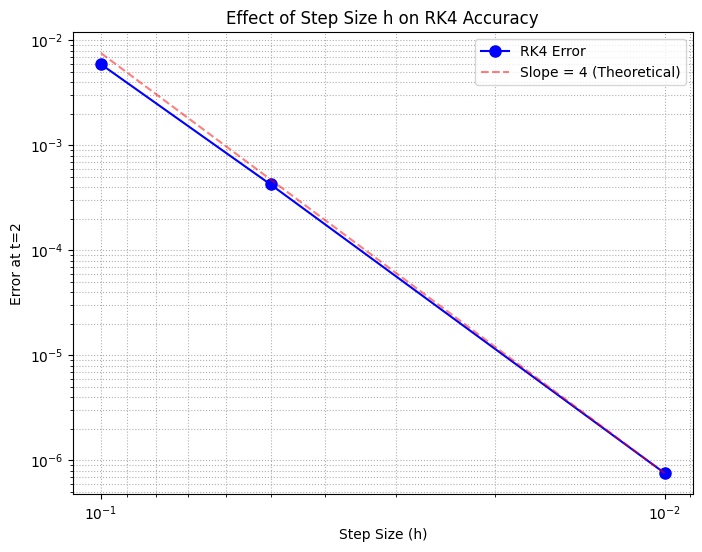

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return t + 2 * x * t

def exact_solution(t):
    return 0.5 * (np.exp(t**2) - 1)

def rk4_solve(h):
    t_end = 2.0
    N = int(np.round(t_end / h))
    t = 0.0
    x = 0.0
    
    for _ in range(N):
        k1 = f(t, x)
        k2 = f(t + 0.5*h, x + 0.5*h*k1)
        k3 = f(t + 0.5*h, x + 0.5*h*k2)
        k4 = f(t + h, x + h*k3)
        x = x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
    return x

h_values = [0.1, 0.05, 0.01]
exact_val = exact_solution(2.0)
errors = []

print(f"{'h':<10} {'Numerical x(2)':<20} {'Exact x(2)':<20} {'Error':<20}")
print("-" * 70)

for h in h_values:
    num_val = rk4_solve(h)
    error = np.abs(exact_val - num_val)
    errors.append(error)
    print(f"{h:<10.2f} {num_val:<20.8f} {exact_val:<20.8f} {error:<20.8e}")


plt.figure(figsize=(8, 6))
plt.loglog(h_values, errors, 'bo-', markersize=8, label='RK4 Error')


ref_line = [errors[-1] * (h / h_values[-1])**4 for h in h_values]
plt.loglog(h_values, ref_line, 'r--', alpha=0.5, label='Slope = 4 (Theoretical)')

plt.xlabel('Step Size (h)')
plt.ylabel('Error at t=2')
plt.title('Effect of Step Size h on RK4 Accuracy')
plt.grid(True, which="both", ls=":")
plt.legend()
plt.gca().invert_xaxis() 
plt.show()

4-2-1

In [ ]:
import numpy as np

def F(V):
    return 0.0039 + 0.0058 / (1 + np.exp((V - 35) / 5))

def baseball_rhs(t, Y, params):
    x, y, z, vx, vy, vz = Y
    B, omega, phi, g = params
    
    V = np.sqrt(vx**2 + vy**2 + vz**2)
    FV = F(V)
    
    ax = -FV * V * vx
    ay = -FV * V * vy + B * omega * V * np.cos(phi)
    az = -FV * V * vz - g - B * omega * V * np.sin(phi)

    return np.array([vx, vy, vz, ax, ay, az])

def rk4_step(f, t, Y, dt, params):
    k1 = f(t, Y, params)
    k2 = f(t + dt/2, Y + dt*k1/2, params)
    k3 = f(t + dt/2, Y + dt*k2/2, params)
    k4 = f(t + dt, Y + dt*k3, params)
    return Y + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

def solve_trajectory(h_init, theta_deg, v0, params, dt=0.001):
    theta = np.radians(theta_deg)
    
    Y = np.array([
        0.0,                # x
        0.0,                # y
        h_init,             # z
        v0 * np.cos(theta), # vx
        0.0,                # vy
        v0 * np.sin(theta)  # vz
    ])
    
    t = 0.0
    
    trajectory = [Y.copy()] 
    
    while Y[0] < 18.39 and Y[2] >= 0:
        Y = rk4_step(baseball_rhs, t, Y, dt, params)
        t += dt
        trajectory.append(Y.copy()) 
        
    return np.array(trajectory) 

4-2-2

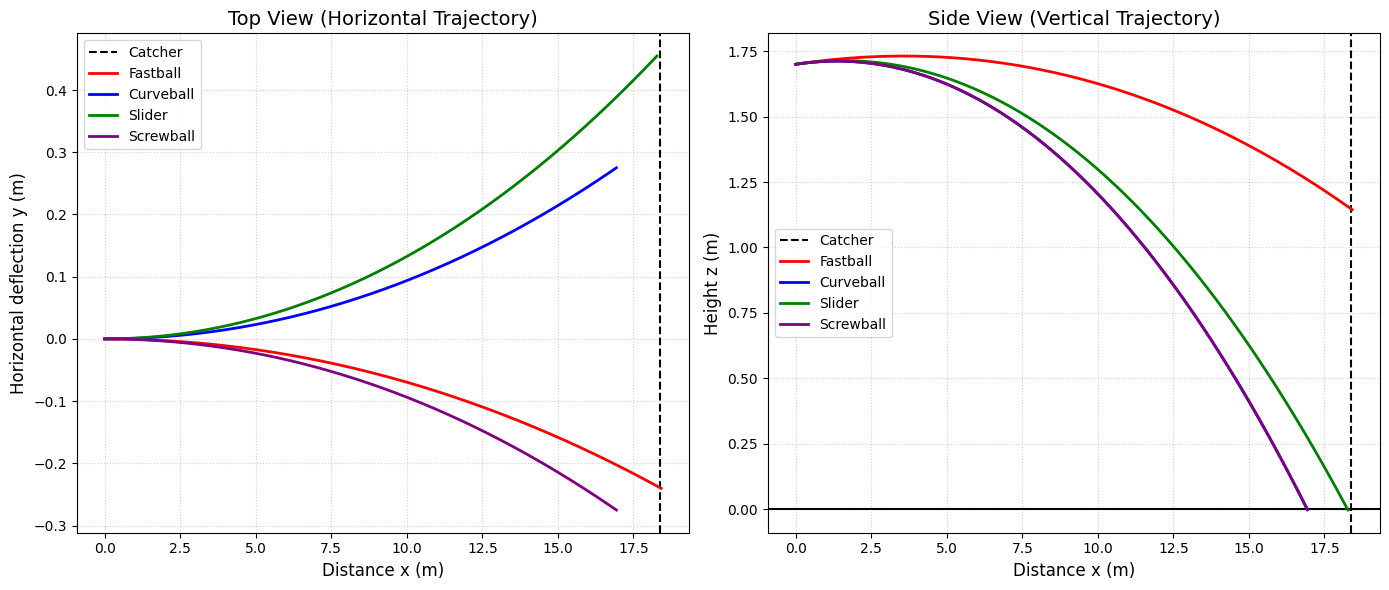

In [6]:
import numpy as np
import matplotlib.pyplot as plt

B = 4.1e-4
g = 9.81
target_x = 18.39   # 포수 위치 (m)
h_init = 1.7       # 투구 높이 (m)
theta_deg = 1.0    # 상승 각도 (도)
omega_rpm = 1800   # 회전수 (rpm)
omega = omega_rpm * (2 * np.pi / 60) 

def F(V):

    return 0.0039 + 0.0058 / (1 + np.exp((V - 35) / 5))

def baseball_rhs(t, Y, params):
    x, y, z, vx, vy, vz = Y
    phi_rad = params 
    
    V = np.sqrt(vx**2 + vy**2 + vz**2)
    FV = F(V)
    
    
    ax = -FV * V * vx
    ay = -FV * V * vy + B * omega * V * np.cos(phi_rad)
    az = -FV * V * vz - g - B * omega * V * np.sin(phi_rad)
    
    return np.array([vx, vy, vz, ax, ay, az])

def rk4_step(f, t, Y, dt, params):
    k1 = f(t, Y, params)
    k2 = f(t + dt/2, Y + dt*k1/2, params)
    k3 = f(t + dt/2, Y + dt*k2/2, params)
    k4 = f(t + dt, Y + dt*k3, params)
    return Y + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

def solve_pitch(v0, phi_deg):
    theta_rad = np.radians(theta_deg)
    phi_rad = np.radians(phi_deg)
    
    Y = np.array([
        0.0, 
        0.0, 
        h_init, 
        v0 * np.cos(theta_rad), 
        0.0, 
        v0 * np.sin(theta_rad)
    ])
    
    t = 0.0
    dt = 0.001 
    
    trajectory = [Y.copy()]

    while Y[0] < target_x and Y[2] >= 0:
        Y = rk4_step(baseball_rhs, t, Y, dt, phi_rad)
        t += dt
        trajectory.append(Y.copy())
        
    return np.array(trajectory)

pitches = {
    "Fastball":  {"v0": 40, "phi": 225, "color": "red"},
    "Curveball": {"v0": 30, "phi": 45,  "color": "blue"},
    "Slider":    {"v0": 30, "phi": 0,   "color": "green"},
    "Screwball": {"v0": 30, "phi": 135, "color": "purple"}
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax1 = axes[0]
ax1.set_title("Top View (Horizontal Trajectory)", fontsize=14)
ax1.set_xlabel("Distance x (m)", fontsize=12)
ax1.set_ylabel("Horizontal deflection y (m)", fontsize=12)
ax1.axvline(target_x, color='k', linestyle='--', label='Catcher')
ax1.grid(True, linestyle=':', alpha=0.6)


ax2 = axes[1]
ax2.set_title("Side View (Vertical Trajectory)", fontsize=14)
ax2.set_xlabel("Distance x (m)", fontsize=12)
ax2.set_ylabel("Height z (m)", fontsize=12)
ax2.axvline(target_x, color='k', linestyle='--', label='Catcher')
ax2.axhline(0, color='k', linewidth=1.5) # 지면
ax2.grid(True, linestyle=':', alpha=0.6)


for name, data in pitches.items():
    traj = solve_pitch(data["v0"], data["phi"])
    
    x = traj[:, 0]
    y = traj[:, 1]
    z = traj[:, 2]
    
    ax1.plot(x, y, color=data["color"], linewidth=2, label=name)
    ax2.plot(x, z, color=data["color"], linewidth=2, label=name)

ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()